In [1]:
# Cell 1 - Load preprocessed time-series data

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

input_path = "../dataset/CMI_timeseries_preprocessed_outputs.pkl"

with open(input_path, "rb") as f:
    data = pickle.load(f)

CMI_timeseries_preprocessed = data["CMI_timeseries_preprocessed"]
CMI_timeseries_global_scaled = data["CMI_timeseries_global_scaled"]
CMI_timeseries_subject_scaled = data["CMI_timeseries_subject_scaled"]

signal_cols = data["signal_cols"]
id_col = data["id_col"]
target_col = data["target_col"]

print("Number of preprocessed time series:", len(CMI_timeseries_preprocessed))
print("Available signal columns:", signal_cols)
print("ID column:", id_col)
print("Target column:", target_col)

print("\nExample time series shape:")
print(CMI_timeseries_preprocessed[0].shape)

print("\nExample columns:")
print(CMI_timeseries_preprocessed[0].columns.tolist())

Number of preprocessed time series: 4310
Available signal columns: ['X', 'Y', 'Z', 'enmo', 'anglez', 'light']
ID column: id
Target column: sii_binary

Example time series shape:
(200, 13)

Example columns:
['X', 'Y', 'Z', 'enmo', 'anglez', 'non-wear_flag', 'light', 'battery_voltage', 'weekday', 'quarter', 'relative_date_PCIAT', 'id', 'sii_binary']


Selected subject id: 2265
Target class: 0
Signal: enmo
Time series length: 200


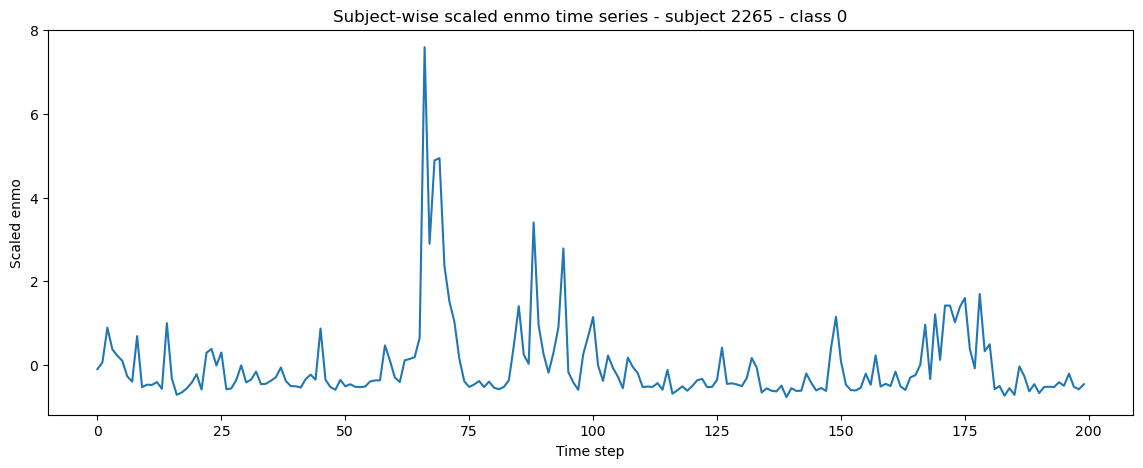

In [2]:
# Cell 2 - Select and visualize one univariate time series

signal_to_analyze = "enmo"

# We start from one subject for interpretability
example_idx = 0

# Use subject-wise scaled data for motif/discord discovery,
# because motifs and discords are shape-based subsequence patterns
example_ts_df = CMI_timeseries_subject_scaled[example_idx]

ts = example_ts_df[signal_to_analyze].to_numpy()

subject_id = example_ts_df[id_col].iloc[0]
target_value = example_ts_df[target_col].iloc[0]

print("Selected subject id:", subject_id)
print("Target class:", target_value)
print("Signal:", signal_to_analyze)
print("Time series length:", len(ts))

plt.figure(figsize=(14, 5))
plt.plot(ts)
plt.title(f"Subject-wise scaled {signal_to_analyze} time series - subject {subject_id} - class {target_value}")
plt.xlabel("Time step")
plt.ylabel(f"Scaled {signal_to_analyze}")
plt.show()

### Selection of a univariate time series for Matrix Profile analysis

We selected the `enmo` signal for one subject as the first example for Matrix Profile analysis. The `enmo` variable is used because it is directly interpretable as a proxy for physical activity intensity.

The time series is subject-wise standardized, meaning that values are expressed relative to the subject's own average and standard deviation. This is useful for motif and discord discovery because these methods focus on temporal shapes rather than absolute signal magnitude.

The selected time series shows several activity peaks, especially around the middle of the sequence. These peaks may correspond to meaningful activity bursts. Matrix Profile analysis will allow us to identify repeated subsequences, called motifs, and unusual subsequences, called discords.

In [3]:
# Cell 3 - Install/import STUMPY for Matrix Profile computation

import sys

try:
    import stumpy
    print("stumpy is already installed.")
except ModuleNotFoundError:
    print("stumpy not found. Installing...")
    !{sys.executable} -m pip install stumpy
    import stumpy
    print("stumpy installed and imported successfully.")

stumpy is already installed.


In [5]:
# Cell 4 - Compute Matrix Profile for the selected univariate time series

m = 12  # subsequence length: 12 time steps = 6 hours

# STUMPY requires float64 input
ts = ts.astype(np.float64)

matrix_profile = stumpy.stump(ts, m=m)

# STUMPY returns several columns.
# Column 0 = Matrix Profile values
# Column 1 = Matrix Profile nearest-neighbor indices
mp_values = matrix_profile[:, 0].astype(float)
mp_indices = matrix_profile[:, 1].astype(int)

print("Time series length:", len(ts))
print("Subsequence length m:", m)
print("Number of subsequences:", len(ts) - m + 1)
print("Matrix Profile length:", len(mp_values))

print("\nFirst 10 Matrix Profile values:")
print(mp_values[:10])

print("\nFirst 10 Matrix Profile nearest-neighbor indices:")
print(mp_indices[:10])

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Time series length: 200
Subsequence length m: 12
Number of subsequences: 189
Matrix Profile length: 189

First 10 Matrix Profile values:
[2.00208917 2.04895886 1.97041694 2.41532167 2.01004211 1.61831623
 1.60038615 1.57758257 1.51415592 1.14204329]

First 10 Matrix Profile nearest-neighbor indices:
[ 86  87 172 121  84  85  86  87 109  40]


### Matrix Profile computation

We computed the Matrix Profile for the selected univariate `enmo` time series using a subsequence length `m = 12`. Since each time step corresponds to 30 minutes, this window length represents a 6-hour temporal pattern.

The original time series has length 200. Therefore, the number of possible subsequences of length 12 is:

`200 - 12 + 1 = 189`

Accordingly, the Matrix Profile contains 189 values, one for each possible subsequence.

Each Matrix Profile value represents the distance between a subsequence and its nearest neighbor elsewhere in the same time series. Low Matrix Profile values indicate subsequences that are similar to another subsequence and are therefore candidate motifs. High Matrix Profile values indicate subsequences that are very different from all others and are therefore candidate discords or anomalies.

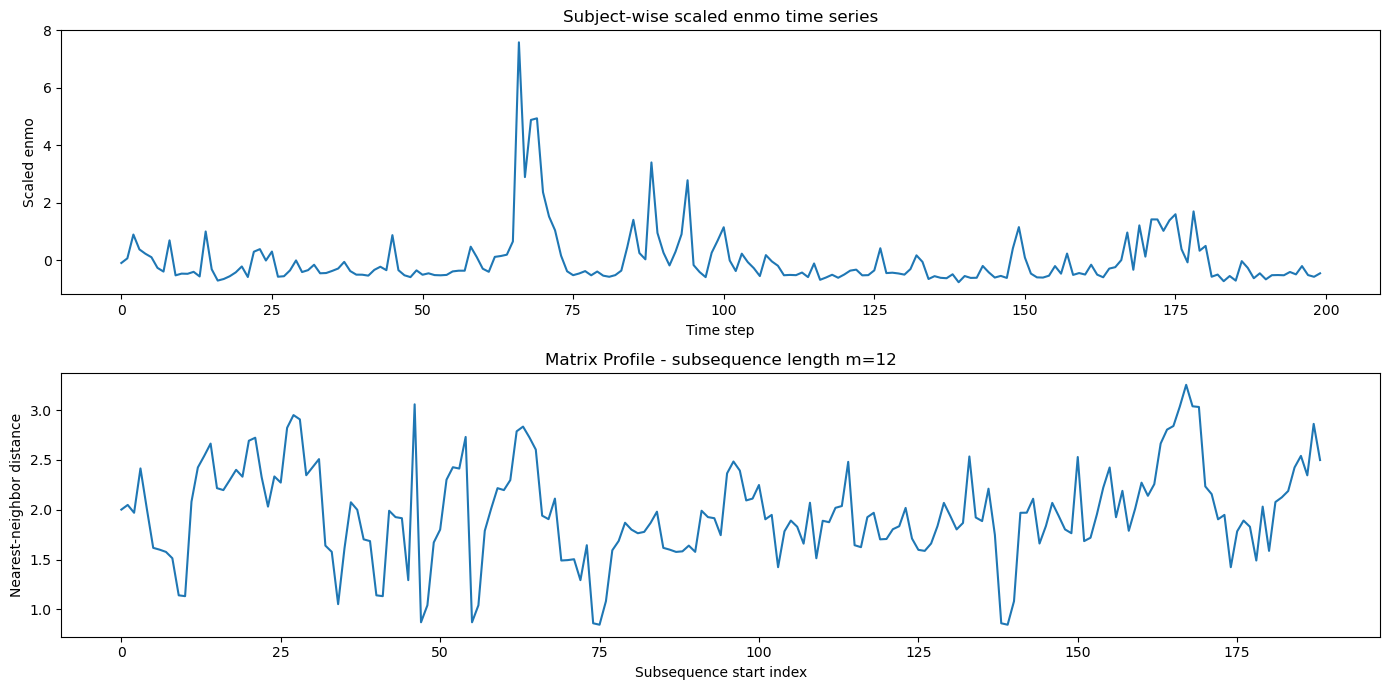

In [6]:
# Cell 5 - Plot the time series and its Matrix Profile

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

axes[0].plot(ts)
axes[0].set_title(f"Subject-wise scaled {signal_to_analyze} time series")
axes[0].set_xlabel("Time step")
axes[0].set_ylabel(f"Scaled {signal_to_analyze}")

axes[1].plot(mp_values)
axes[1].set_title(f"Matrix Profile - subsequence length m={m}")
axes[1].set_xlabel("Subsequence start index")
axes[1].set_ylabel("Nearest-neighbor distance")

plt.tight_layout()
plt.show()


### Matrix Profile visualization

The upper plot shows the subject-wise standardized `enmo` time series for the selected subject, while the lower plot shows the corresponding Matrix Profile computed with subsequence length `m = 12`.

Since each time step represents a 30-minute interval, `m = 12` corresponds to a 6-hour subsequence. Therefore, each Matrix Profile value measures how similar a 6-hour activity pattern is to its nearest neighbor elsewhere in the same time series.

Low Matrix Profile values indicate subsequences that have a close match in another part of the time series. These regions are candidate motifs, i.e. repeated temporal patterns. High Matrix Profile values indicate subsequences that are far from their nearest neighbor and are therefore candidate discords or anomalous patterns.

In this example, the Matrix Profile shows several local minima, suggesting the presence of repeated activity patterns. It also contains some high-value regions, which may correspond to unusual subsequences.

Top motif subsequence start index: 75
Nearest-neighbor subsequence start index: 139
Matrix Profile distance: 0.8469898485237009


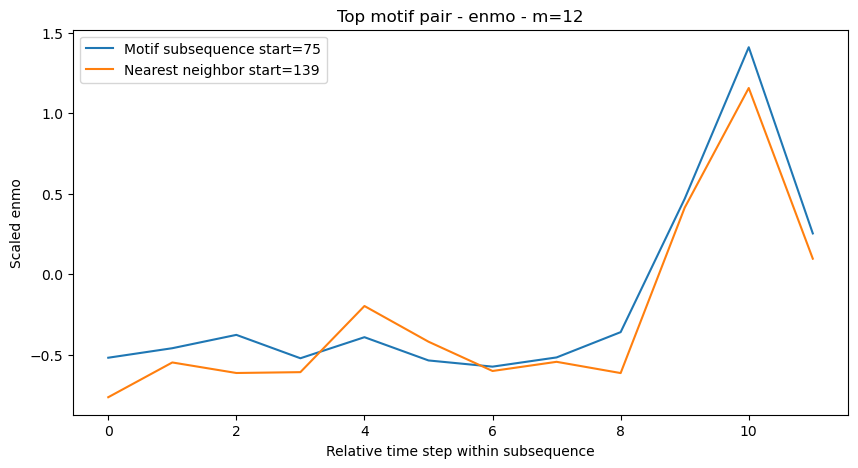

In [7]:
# Cell 6 - Extract the top motif pair from the Matrix Profile

motif_idx = np.argmin(mp_values)
nearest_neighbor_idx = mp_indices[motif_idx]

motif_distance = mp_values[motif_idx]

print("Top motif subsequence start index:", motif_idx)
print("Nearest-neighbor subsequence start index:", nearest_neighbor_idx)
print("Matrix Profile distance:", motif_distance)

motif_subseq = ts[motif_idx : motif_idx + m]
neighbor_subseq = ts[nearest_neighbor_idx : nearest_neighbor_idx + m]

plt.figure(figsize=(10, 5))
plt.plot(motif_subseq, label=f"Motif subsequence start={motif_idx}")
plt.plot(neighbor_subseq, label=f"Nearest neighbor start={nearest_neighbor_idx}")
plt.title(f"Top motif pair - {signal_to_analyze} - m={m}")
plt.xlabel("Relative time step within subsequence")
plt.ylabel(f"Scaled {signal_to_analyze}")
plt.legend()
plt.show()

### Top motif pair

The top motif pair was identified using the minimum value of the Matrix Profile. The motif subsequence starts at time step `75`, while its nearest-neighbor subsequence starts at time step `139`.

The Matrix Profile distance between the two subsequences is approximately `0.847`. This value represents the distance between the two 6-hour activity patterns after subject-wise standardization.

Visually, the two subsequences have a similar temporal shape: both remain relatively low for most of the window and then show a sharp increase near the end. Therefore, this pair can be interpreted as a repeated local activity pattern within the same subject.

A motif does not require the subsequences to be exactly identical. Rather, it identifies subsequences that are highly similar compared with the other subsequences in the same time series.

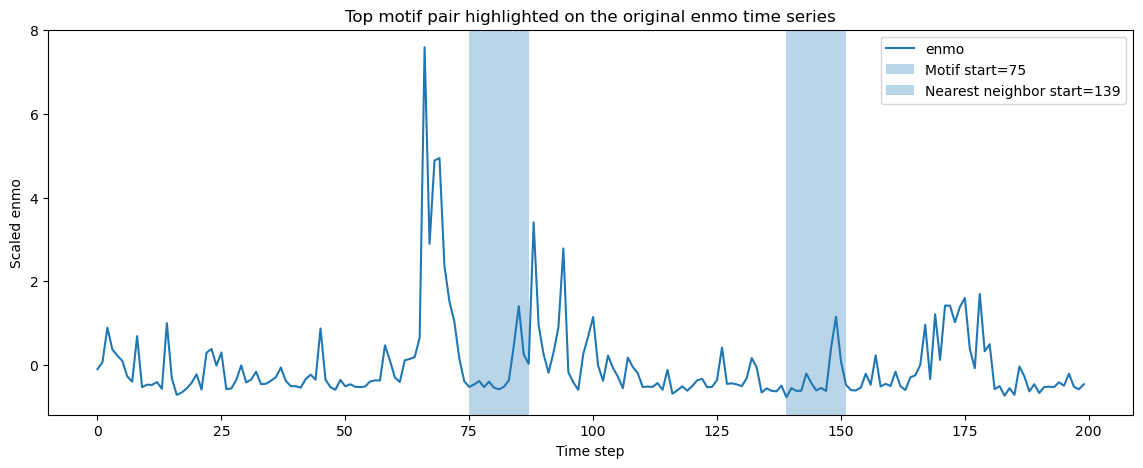

In [8]:
# Cell 7 - Visualize the top motif pair on the original time series

plt.figure(figsize=(14, 5))

plt.plot(ts, label=signal_to_analyze)

plt.axvspan(
    motif_idx,
    motif_idx + m,
    alpha=0.3,
    label=f"Motif start={motif_idx}"
)

plt.axvspan(
    nearest_neighbor_idx,
    nearest_neighbor_idx + m,
    alpha=0.3,
    label=f"Nearest neighbor start={nearest_neighbor_idx}"
)

plt.title(f"Top motif pair highlighted on the original {signal_to_analyze} time series")
plt.xlabel("Time step")
plt.ylabel(f"Scaled {signal_to_analyze}")
plt.legend()
plt.show()

### Motif pair localization in the original time series

We highlighted the top motif pair directly on the original standardized `enmo` time series.

The first motif subsequence starts at time step `75` and covers the interval from `75` to `87`. Its nearest-neighbor subsequence starts at time step `139` and covers the interval from `139` to `151`.

Both subsequences correspond to relatively low-activity intervals followed by a local increase in `enmo`. This explains why they are identified as the most similar 6-hour activity patterns in the selected subject's time series.

This visualization is important because it connects the Matrix Profile result back to the original temporal signal. The motif is not just a pair of indices: it represents a repeated temporal behavior within the subject's activity profile.

Top discord subsequence start index: 167
Matrix Profile distance: 3.2541963529482785


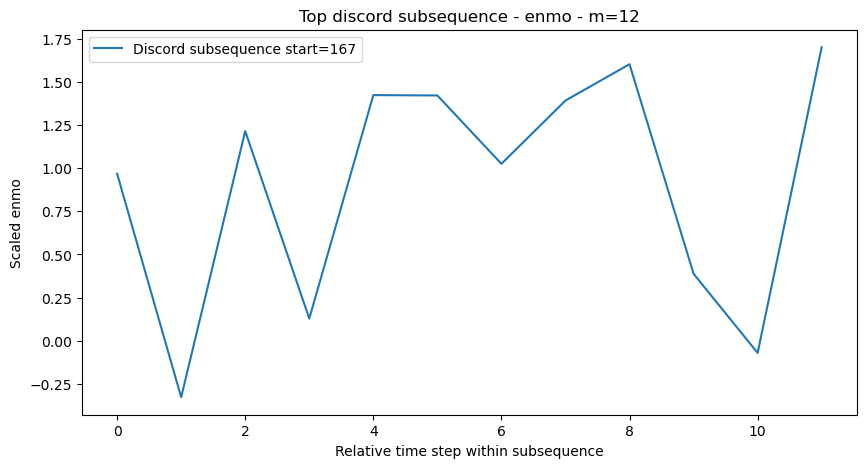

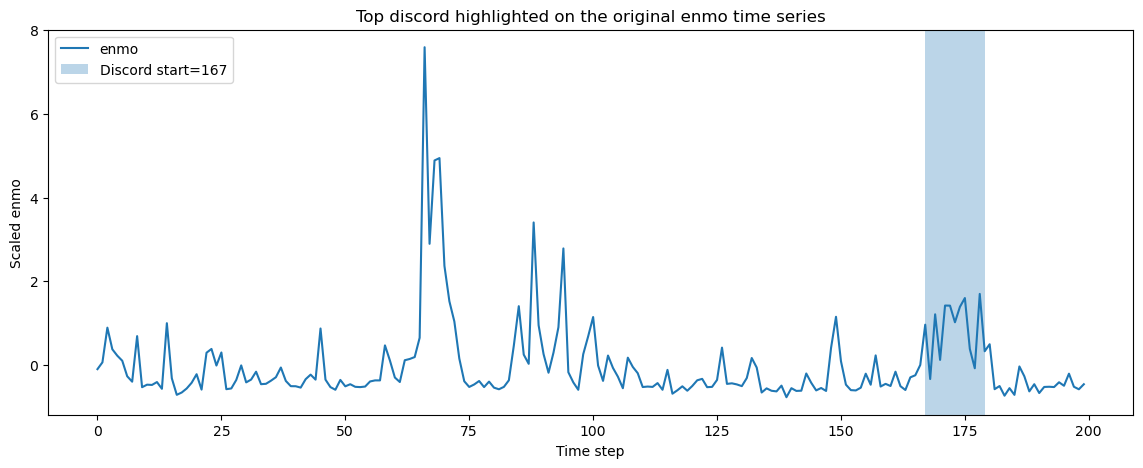

In [9]:
# Cell 8 - Extract and visualize the top discord

discord_idx = np.argmax(mp_values)
discord_distance = mp_values[discord_idx]

print("Top discord subsequence start index:", discord_idx)
print("Matrix Profile distance:", discord_distance)

discord_subseq = ts[discord_idx : discord_idx + m]

plt.figure(figsize=(10, 5))
plt.plot(discord_subseq, label=f"Discord subsequence start={discord_idx}")
plt.title(f"Top discord subsequence - {signal_to_analyze} - m={m}")
plt.xlabel("Relative time step within subsequence")
plt.ylabel(f"Scaled {signal_to_analyze}")
plt.legend()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(ts, label=signal_to_analyze)
plt.axvspan(
    discord_idx,
    discord_idx + m,
    alpha=0.3,
    label=f"Discord start={discord_idx}"
)
plt.title(f"Top discord highlighted on the original {signal_to_analyze} time series")
plt.xlabel("Time step")
plt.ylabel(f"Scaled {signal_to_analyze}")
plt.legend()
plt.show()

### Top discord discovery

We identified the top discord by selecting the subsequence with the highest Matrix Profile value. The top discord starts at time step `167`, and its Matrix Profile distance is approximately `3.254`.

This means that the 6-hour subsequence starting at time step `167` is the most unusual subsequence in the selected `enmo` time series. In other words, even its nearest neighbor is relatively far away, indicating that this pattern is not repeated elsewhere in the same subject's activity profile.

The highlighted discord corresponds to a region with several consecutive positive activity values and a fluctuating temporal shape. Although the time series contains larger peaks earlier, the discord is selected because its overall subsequence shape is the most unique according to the Matrix Profile.

This illustrates the difference between a simple point anomaly and a time-series discord. A discord is not necessarily the single largest value in the series; it is the subsequence whose shape is most dissimilar from all other subsequences.

In [10]:
# Cell 9 - Extract top-k motif pairs with exclusion zone

def apply_exclusion_zone(profile, idx, exclusion_zone):
    """
    Set Matrix Profile values around idx to infinity
    so that overlapping/nearly overlapping subsequences are not selected again.
    """
    start = max(0, idx - exclusion_zone)
    end = min(len(profile), idx + exclusion_zone + 1)
    profile[start:end] = np.inf


k_motifs = 3
exclusion_zone = m  # exclude subsequences starting within m points

mp_motifs = mp_values.copy()
top_motifs = []

for k in range(k_motifs):
    motif_idx = np.argmin(mp_motifs)
    nn_idx = mp_indices[motif_idx]
    motif_distance = mp_values[motif_idx]
    
    top_motifs.append({
        "motif_rank": k + 1,
        "motif_start": motif_idx,
        "nearest_neighbor_start": nn_idx,
        "distance": motif_distance
    })
    
    # Exclude both the motif and its nearest neighbor neighborhoods
    apply_exclusion_zone(mp_motifs, motif_idx, exclusion_zone)
    apply_exclusion_zone(mp_motifs, nn_idx, exclusion_zone)

top_motifs_df = pd.DataFrame(top_motifs)

display(top_motifs_df)

,motif_rank,motif_start,nearest_neighbor_start,distance
0,1,75,139,0.846990
1,2,47,55,0.871409
2,3,34,55,1.053457


### Top-k motif pairs

We extracted the top-3 motif pairs using the Matrix Profile. To avoid repeatedly selecting overlapping subsequences, we applied an exclusion zone around each selected motif and its nearest neighbor.

The strongest motif pair is the one with the smallest Matrix Profile distance. In this case, the top motif starts at time step `75` and its nearest neighbor starts at time step `139`, with a distance of approximately `0.847`.

The second and third motif pairs have slightly larger distances, meaning that they are less similar than the top motif pair but still represent repeated local temporal patterns in the selected `enmo` time series.

Some motif pairs may share a nearest-neighbor subsequence. This can happen because nearest-neighbor relationships in the Matrix Profile are not necessarily symmetric and because we are using a simple manual top-k extraction procedure. Nevertheless, the result is useful for identifying repeated activity patterns and for connecting the implementation to the Matrix Profile theory.

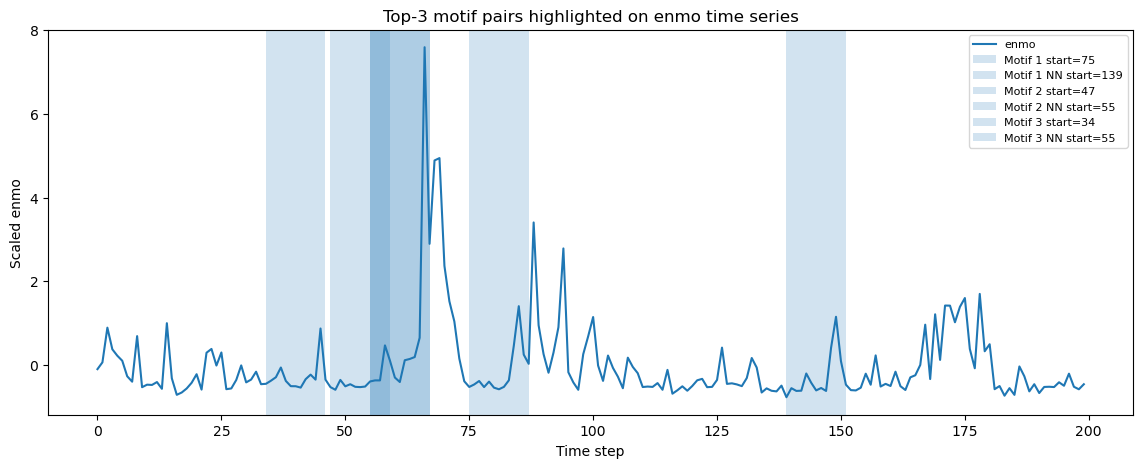

In [11]:
# Cell 10 - Visualize top-k motif pairs on the original time series

plt.figure(figsize=(14, 5))
plt.plot(ts, label=signal_to_analyze)

for _, row in top_motifs_df.iterrows():
    rank = int(row["motif_rank"])
    start_1 = int(row["motif_start"])
    start_2 = int(row["nearest_neighbor_start"])
    
    plt.axvspan(
        start_1,
        start_1 + m,
        alpha=0.20,
        label=f"Motif {rank} start={start_1}"
    )
    
    plt.axvspan(
        start_2,
        start_2 + m,
        alpha=0.20,
        label=f"Motif {rank} NN start={start_2}"
    )

plt.title(f"Top-{k_motifs} motif pairs highlighted on {signal_to_analyze} time series")
plt.xlabel("Time step")
plt.ylabel(f"Scaled {signal_to_analyze}")
plt.legend(loc="upper right", fontsize=8)
plt.show()

### Top-3 motif pairs visualization

We visualized the top-3 motif pairs on the original standardized `enmo` time series. The highlighted regions show where the repeated subsequences occur in the temporal signal.

The detected motifs are mostly located in low-to-moderate activity regions, often close to local transitions or small peaks. This confirms that motif discovery is based on repeated temporal shapes, not simply on the largest signal values.

Some highlighted regions are close to each other or partially overlapping. This is due to the manual top-k extraction procedure and the chosen exclusion zone. The result shows that motif discovery depends on both the subsequence length `m` and the exclusion strategy used to avoid selecting trivial overlapping matches.

Overall, the top-k motifs identify repeated 6-hour activity patterns within the selected subject's `enmo` signal. These repeated patterns may later be compared with shapelets: motifs are unsupervised repeated subsequences, while shapelets are discriminative subsequences selected for classification.

In [15]:
# Cell 11 corrected - Extract top-k discords excluding motif regions

k_discords = 3
exclusion_zone = m

mp_discords = mp_values.copy()

# First, exclude all motif regions and their nearest-neighbor regions
for _, row in top_motifs_df.iterrows():
    motif_start = int(row["motif_start"])
    nn_start = int(row["nearest_neighbor_start"])
    
    apply_exclusion_zone(mp_discords, motif_start, exclusion_zone)
    apply_exclusion_zone(mp_discords, nn_start, exclusion_zone)

top_discords = []

for k in range(k_discords):
    discord_idx = np.argmax(mp_discords)
    discord_distance = mp_values[discord_idx]
    
    top_discords.append({
        "discord_rank": k + 1,
        "discord_start": discord_idx,
        "distance": discord_distance
    })
    
    apply_exclusion_zone(mp_discords, discord_idx, exclusion_zone)

top_discords_df = pd.DataFrame(top_discords)

display(top_discords_df)

,discord_rank,discord_start,distance
0,1,22,2.329490
1,2,10,1.133599
2,3,0,2.002089


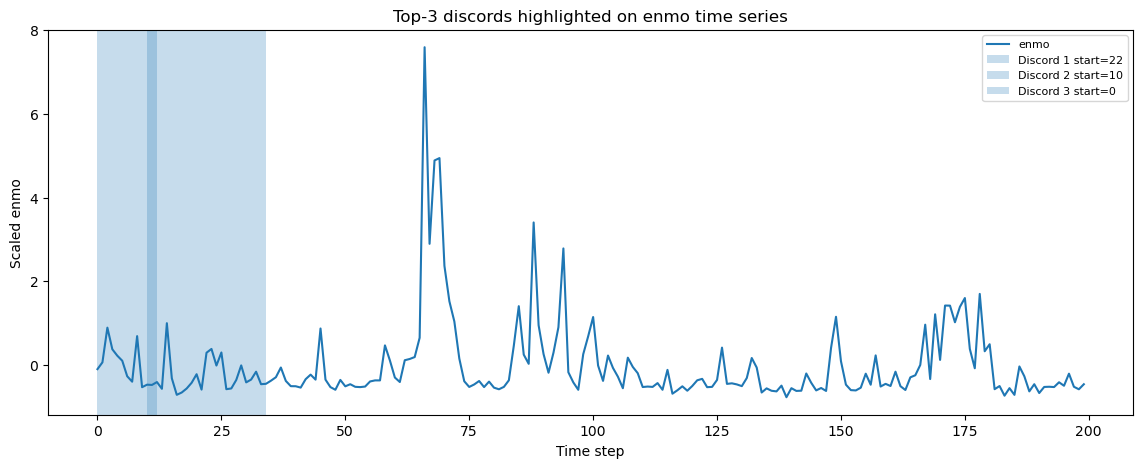

In [16]:
# Cell 12 - Visualize top-k discords on the original time series

plt.figure(figsize=(14, 5))
plt.plot(ts, label=signal_to_analyze)

for _, row in top_discords_df.iterrows():
    rank = int(row["discord_rank"])
    start = int(row["discord_start"])
    
    plt.axvspan(
        start,
        start + m,
        alpha=0.25,
        label=f"Discord {rank} start={start}"
    )

plt.title(f"Top-{k_discords} discords highlighted on {signal_to_analyze} time series")
plt.xlabel("Time step")
plt.ylabel(f"Scaled {signal_to_analyze}")
plt.legend(loc="upper right", fontsize=8)
plt.show()

### Top-3 discords visualization

We visualized the top-3 discords on the original standardized `enmo` time series. The detected discords are concentrated in the later part of the sequence, approximately between time steps `143` and `179`.

This region contains several moderate activity increases and fluctuations. Although the largest individual peak in the time series occurs earlier, around time steps `65–70`, the Matrix Profile identifies the later region as more anomalous because its overall subsequence shape is less similar to all other subsequences.

This highlights an important distinction: a time-series discord is not simply a single extreme value. Instead, it is a subsequence whose temporal pattern is unusual compared with the rest of the series.

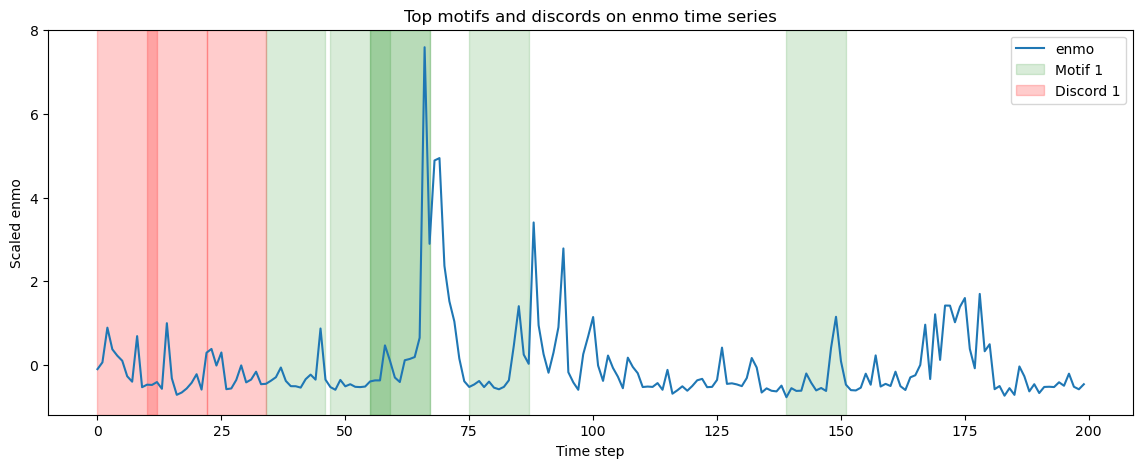

In [17]:
# Cell 13 - Visualize motifs and discords together

plt.figure(figsize=(14, 5))
plt.plot(ts, label=signal_to_analyze)

# Highlight motif regions
for _, row in top_motifs_df.iterrows():
    rank = int(row["motif_rank"])
    start_1 = int(row["motif_start"])
    start_2 = int(row["nearest_neighbor_start"])
    
    plt.axvspan(
        start_1,
        start_1 + m,
        alpha=0.15,
        color="green",
        label=f"Motif {rank}" if rank == 1 else None
    )
    
    plt.axvspan(
        start_2,
        start_2 + m,
        alpha=0.15,
        color="green"
    )

# Highlight discord regions
for _, row in top_discords_df.iterrows():
    rank = int(row["discord_rank"])
    start = int(row["discord_start"])
    
    plt.axvspan(
        start,
        start + m,
        alpha=0.20,
        color="red",
        label=f"Discord {rank}" if rank == 1 else None
    )

plt.title(f"Top motifs and discords on {signal_to_analyze} time series")
plt.xlabel("Time step")
plt.ylabel(f"Scaled {signal_to_analyze}")
plt.legend(loc="upper right")
plt.show()